<a href="https://colab.research.google.com/github/m22aie202/FM_GenAI/blob/main/m22aie202_Assignment_2_Attempt_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [151]:
!pip install datasets torchtext

In [152]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import re
import numpy as np
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt

In [153]:
#first 50,000 sentence pairs
dataset = load_dataset("OscarNav/spa-eng", split="train[:50000]")

In [154]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text

In [155]:
print(dataset[0])

{'eng': 'When the curtain went up, the stage was dark.', 'spa': 'Al levantarse el telón, la escena estaba oscura.'}


In [156]:
pairs = []

for item in dataset:
    en = clean_text(item["eng"])
    es = "[start] " + clean_text(item["spa"]) + " [end]"
    #es = clean_text(item["spa"])
    pairs.append((en, es))

In [157]:
max_vocab = 15000
max_len = 20

en_counter = Counter()
es_counter = Counter()

for en, es in pairs:
    en_counter.update(en.split())
    es_counter.update(es.split())

en_vocab = ["<pad>", "<unk>"] + [w for w,_ in en_counter.most_common(max_vocab-2)]
es_vocab = ["<pad>", "<unk>"] + [w for w,_ in es_counter.most_common(max_vocab-2)]

en_word2idx = {w:i for i,w in enumerate(en_vocab)}
es_word2idx = {w:i for i,w in enumerate(es_vocab)}

en_idx2word = {i:w for w,i in en_word2idx.items()}
es_idx2word = {i:w for w,i in es_word2idx.items()}

In [158]:
# def encode(sentence):
#     tokens = sentence.split()[:max_len]
#     ids = [word2idx.get(t, word2idx["<unk>"]) for t in tokens]
#     ids += [word2idx["<pad>"]] * (max_len - len(ids))
#     return ids

def encode_en(sentence):
    tokens = sentence.split()[:max_len]
    ids = [en_word2idx.get(t, en_word2idx["<unk>"]) for t in tokens]
    ids += [en_word2idx["<pad>"]] * (max_len - len(ids))
    return ids

def encode_es(sentence):
    tokens = sentence.split()[:max_len]
    ids = [es_word2idx.get(t, es_word2idx["<unk>"]) for t in tokens]
    ids += [es_word2idx["<pad>"]] * (max_len - len(ids))
    return ids

In [159]:
# data = [(encode(en), encode(es)) for en, es in pairs]
data = [(encode_en(en), encode_es(es)) for en, es in pairs]

train_data = data[:45000]
val_data   = data[45000:50000]

In [160]:
def create_loader(dataset, batch_size=64):
    src = torch.tensor([x[0] for x in dataset])
    tgt = torch.tensor([x[1] for x in dataset])
    return torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(src, tgt),
        batch_size=batch_size,
        shuffle=True
    )

train_loader = create_loader(train_data, batch_size=128)
val_loader   = create_loader(val_data)

In [161]:
def create_padding_mask(seq, pad_idx):
    mask = (seq == pad_idx)
    return mask.unsqueeze(1).unsqueeze(2)

In [162]:
def create_causal_mask(size, device):
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask.bool().to(device)

In [163]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model=256, max_len=20):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             -(math.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(position*div_term)
        pe[:,1::2] = torch.cos(position*div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self,x):
        return x + self.pe[:,:x.size(1)].to(x.device)

In [164]:
class ScaledDotProductAttention(nn.Module):
    def forward(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2,-1)) / math.sqrt(Q.size(-1))
        if mask is not None:
            scores = scores + mask
        attn = F.softmax(scores, dim=-1)
        return torch.matmul(attn, V)

In [165]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=256, heads=4):
        super().__init__()
        self.heads = heads
        self.d_k = d_model // heads

        self.W_q = nn.Linear(d_model,d_model)
        self.W_k = nn.Linear(d_model,d_model)
        self.W_v = nn.Linear(d_model,d_model)
        self.fc = nn.Linear(d_model,d_model)
        self.dropout = nn.Dropout(0.1)

    def split(self,x):
        b,seq,d = x.size()
        x = x.view(b,seq,self.heads,self.d_k)
        return x.transpose(1,2)

    def forward(self,Q,K,V,mask=None):
        Q = self.split(self.W_q(Q))
        K = self.split(self.W_k(K))
        V = self.split(self.W_v(V))

        scores = torch.matmul(Q,K.transpose(-2,-1)) / math.sqrt(self.d_k)

        if mask is not None:
          scores = scores.masked_fill(mask, -1e9)

        attn = torch.softmax(scores,dim=-1)
        out = torch.matmul(attn,V)

        out = out.transpose(1,2).contiguous()
        out = out.view(out.size(0),-1,self.heads*self.d_k)

        return self.fc(self.dropout(out))

In [166]:
class EncoderLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn = MultiHeadAttention()
        self.norm1 = nn.LayerNorm(256)
        self.norm2 = nn.LayerNorm(256)
        self.ff = nn.Sequential(
            nn.Linear(256,1024),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(1024,256)
        )
        self.dropout = nn.Dropout(0.1)

    def forward(self,x,mask):
        x = self.norm1(x + self.dropout(self.attn(x,x,x,mask)))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x

In [167]:
class DecoderLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.self_attn = MultiHeadAttention()
        self.cross_attn = MultiHeadAttention()
        self.norm1 = nn.LayerNorm(256)
        self.norm2 = nn.LayerNorm(256)
        self.norm3 = nn.LayerNorm(256)

        self.ff = nn.Sequential(
            nn.Linear(256,1024),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(1024,256)
        )
        self.dropout = nn.Dropout(0.1)

    def forward(self,x,enc_out,src_mask,tgt_mask):
        x = self.norm1(x + self.dropout(self.self_attn(x,x,x,tgt_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x,enc_out,enc_out,src_mask)))
        x = self.norm3(x + self.dropout(self.ff(x)))
        return x

In [168]:
class Transformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.src_embed = nn.Embedding(len(en_vocab), 256)
        self.tgt_embed = nn.Embedding(len(es_vocab), 256)
        self.pos = PositionalEncoding()

        self.enc_layers = nn.ModuleList([EncoderLayer() for _ in range(2)])
        self.dec_layers = nn.ModuleList([DecoderLayer() for _ in range(2)])

        self.fc = nn.Linear(256, len(es_vocab))

    def forward(self, src, tgt):

        # ===== Create Masks =====
        src_pad_mask = create_padding_mask(src, en_word2idx["<pad>"])
        tgt_pad_mask = create_padding_mask(tgt, es_word2idx["<pad>"])

        tgt_len = tgt.size(1)
        causal_mask = create_causal_mask(tgt_len, tgt.device)

        # Expand causal mask
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)

        # Combine masks
        tgt_mask = tgt_pad_mask | causal_mask

        # ===== Embedding =====
        src = self.pos(self.src_embed(src))
        tgt = self.pos(self.tgt_embed(tgt))

        # ===== Encoder =====
        for layer in self.enc_layers:
            src = layer(src, src_pad_mask)

        # ===== Decoder =====
        for layer in self.dec_layers:
            tgt = layer(tgt, src, src_pad_mask, tgt_mask)

        return self.fc(tgt)

In [169]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Transformer().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

criterion = nn.CrossEntropyLoss(
    ignore_index=es_word2idx["<pad>"],
    label_smoothing=0.1
)

train_losses = []
val_losses = []

for epoch in range(20):
    model.train()
    total_loss = 0

    for src,tgt in train_loader:
        src,tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()

        output = model(src,tgt[:,:-1])
        loss = criterion(
            output.reshape(-1,len(es_vocab)),
            tgt[:,1:].reshape(-1)
        )

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    train_losses.append(total_loss/len(train_loader))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for src,tgt in val_loader:
            src,tgt = src.to(device), tgt.to(device)
            output = model(src,tgt[:,:-1])
            loss = criterion(
                output.reshape(-1,len(es_vocab)),
                tgt[:,1:].reshape(-1)
            )
            val_loss += loss.item()

    val_losses.append(val_loss/len(val_loader))

    print(f"Epoch {epoch+1}: Train {train_losses[-1]:.4f}, Val {val_losses[-1]:.4f}")

Epoch 1: Train 5.7836, Val 4.6813
Epoch 2: Train 4.3456, Val 3.9780
Epoch 3: Train 3.7258, Val 3.6135
Epoch 4: Train 3.3265, Val 3.3930
Epoch 5: Train 3.0342, Val 3.2602
Epoch 6: Train 2.7661, Val 3.1737
Epoch 7: Train 2.6517, Val 3.1547
Epoch 8: Train 2.5551, Val 3.1113
Epoch 9: Train 2.4683, Val 3.1193
Epoch 10: Train 2.3895, Val 3.0885
Epoch 11: Train 2.2869, Val 3.0763
Epoch 12: Train 2.2467, Val 3.0853
Epoch 13: Train 2.2123, Val 3.0913
Epoch 14: Train 2.1815, Val 3.0727
Epoch 15: Train 2.1495, Val 3.0892
Epoch 16: Train 2.1048, Val 3.0716
Epoch 17: Train 2.0897, Val 3.0796
Epoch 18: Train 2.0746, Val 3.0866
Epoch 19: Train 2.0601, Val 3.0906
Epoch 20: Train 2.0461, Val 3.0903


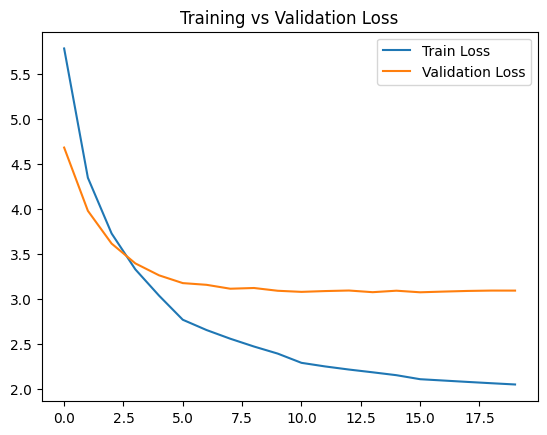

In [173]:
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [174]:
def greedy_decode(model, src_sentence):
    model.eval()
    src = torch.tensor([encode(src_sentence)]).to(device)
    generated = [word2idx["[start]"]]

    for _ in range(20):
        tgt = torch.tensor([generated]).to(device)
        output = model(src,tgt)
        next_token = torch.argmax(
            F.log_softmax(output[:,-1,:],dim=-1),
            dim=-1
        ).item()

        generated.append(next_token)
        if idx2word[next_token] == "[end]":
            break

    return " ".join([idx2word[i] for i in generated])

In [175]:
for i in range(5):
    src = pairs[45000+i][0]
    tgt = pairs[45000+i][1]
    pred = greedy_decode(model, src)

    print("Source English:", src)
    print("Target Spanish:", tgt)
    print("Model Prediction:", pred)
    print("-"*50)

Source English: tom was a judge in an art contest
Target Spanish: [start] tom fue juez en un concurso de arte [end]
Model Prediction: [start] tu date no quiero tom <unk> <unk> <unk> <unk> [end]
--------------------------------------------------
Source English: its my umbrella
Target Spanish: [start] es mi paraguas [end]
Model Prediction: [start] everyone de comida [end]
--------------------------------------------------
Source English: you may choose whichever you want
Target Spanish: [start] tú puedes elegir la que quieras [end]
Model Prediction: [start] didnt car the him be es a es a es car the be [end]
--------------------------------------------------
Source English: i cant eat the apple
Target Spanish: [start] no puedo comerme la manzana [end]
Model Prediction: [start] la if tom united to [end]
--------------------------------------------------
Source English: tom i bet youd be a good teacher
Target Spanish: [start] tom apuesto a que eres un buen profesor [end]
Model Prediction: [